Generating polygons using PuLP (solving support function LPs)...

GEOMETRIC METRICS vs GOAL VALUES

Polygon 1 (random):
  Area         = 63.852  (goal: 12.0)   diff = +51.852
  Centroid     = (0.239, -0.117)  (goal: (0.5, 0.5))  diff = (-0.261, -0.617)
  Perimeter    = 31.176  (goal: 15.0)   diff = +16.176
  Compactness  = 0.826  (goal: 0.75)   diff = +0.076
  Similarity to ref = 1.000 (identical to reference)

Polygon 2 (elongated):
  Area         = 85.883  (goal: 12.0)   diff = +73.883
  Centroid     = (-0.175, 0.348)  (goal: (0.5, 0.5))  diff = (-0.675, -0.152)
  Perimeter    = 37.931  (goal: 15.0)   diff = +22.931
  Compactness  = 0.750  (goal: 0.75)   diff = +0.000
  Similarity to ref = 0.688  (goal: >0.6)  achieved

Polygon 3 (near-regular):
  Area         = 70.148  (goal: 12.0)   diff = +58.148
  Centroid     = (-0.000, 0.000)  (goal: (0.5, 0.5))  diff = (-0.500, -0.500)
  Perimeter    = 31.177  (goal: 15.0)   diff = +16.177
  Compactness  = 0.907  (goal: 0.75)   diff = +0.157
 

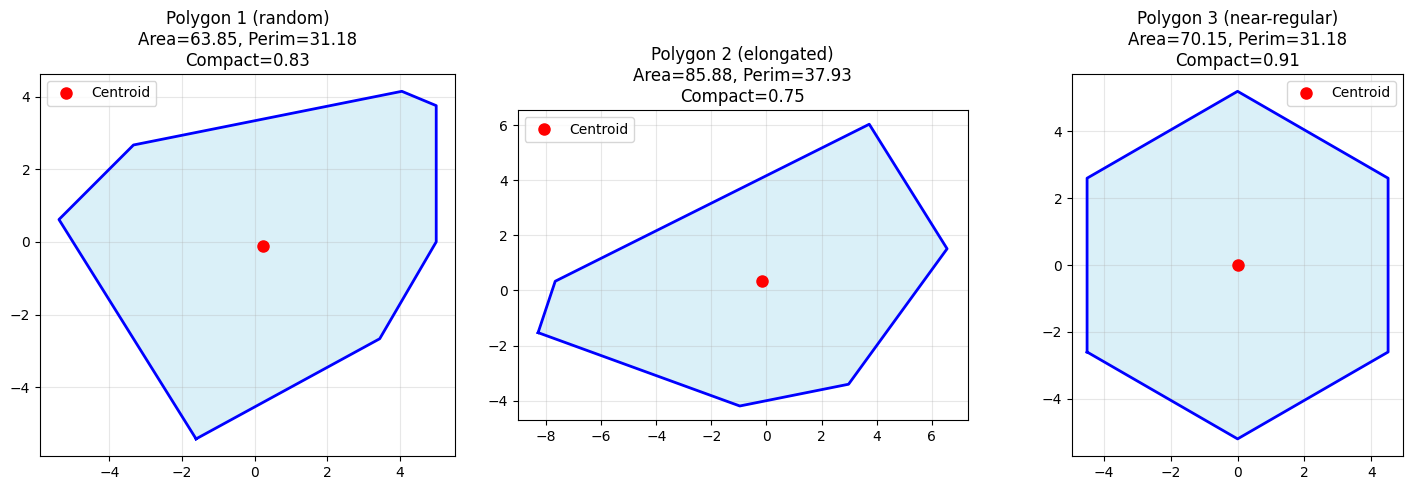


Shape similarity (IoU) matrix:
         P1     P2     P3   
P1  1.000  0.688  0.758  
P2  0.688  1.000  0.653  
P3  0.758  0.653  1.000  

Original vertex‑centroid of Polygon 1: (1.024, 0.441)
After LP adjustment, new vertex‑centroid: (1.500, 1.000) (target (1.5, 1.0))


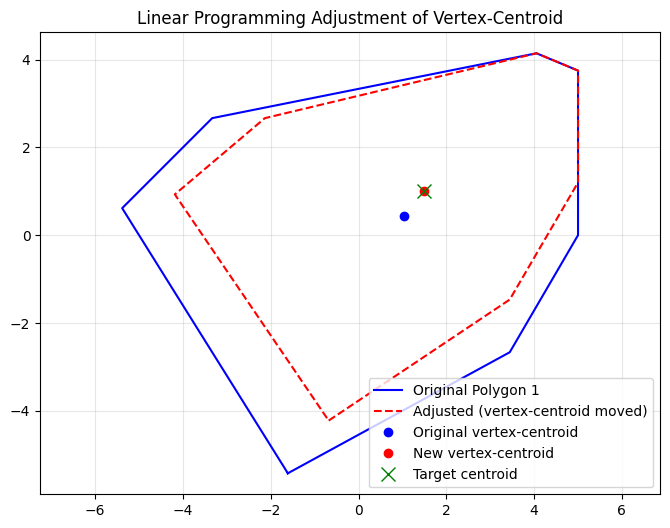

In [1]:
# %% [markdown]
# # Polygon Generation and Analysis using Linear Programming (PuLP)
# 
# This notebook demonstrates how to:
# - Use **PuLP** (Linear Programming) to generate convex polygons from linear constraints.
# - Compute geometric properties: **area**, **centroid**, **boundary length (perimeter)**, **compactness**.
# - Measure **shape similarity** between polygons (Intersection over Union).
# - Compare the obtained values against **user-defined goal values** for each metric.
# 
# The core idea: given a set of linear inequalities (half-planes), we extract the vertices of the convex polygon by solving a series of LPs – maximizing the support function in many directions.
# 
# ## 1. Import required libraries

# %%
import pulp
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon as ShapelyPolygon
from shapely.ops import unary_union
import itertools

# %% [markdown]
# ## 2. Function to compute polygon vertices from linear constraints using PuLP
# 
# The polygon is defined by constraints: `A_i * x + B_i * y <= C_i` for i=1..m.
# We sweep angles `theta` in [0, 2π) and solve:
# ```
# maximize  cos(theta)*x + sin(theta)*y
# subject to A_i x + B_i y <= C_i
# ```
# Each optimal point is a vertex of the convex polygon (support point). Duplicates are removed and points are ordered by angle.

# %%
def polygon_from_constraints(A, B, C, num_angles=360):
    """
    Generate a convex polygon (ordered vertices) from linear constraints.
    
    Parameters:
    A, B, C : lists of floats – coefficients of A_i x + B_i y <= C_i
    num_angles : number of directions to sample
    
    Returns:
    list of (x,y) vertices in counter‑clockwise order, or empty if infeasible/unbounded.
    """
    constraints = []
    prob_base = pulp.LpProblem("SupportFunction", pulp.LpMaximize)
    x = pulp.LpVariable("x", lowBound=None, cat='Continuous')
    y = pulp.LpVariable("y", lowBound=None, cat='Continuous')
    
    # Add all linear constraints
    for a, b, c in zip(A, B, C):
        prob_base += a*x + b*y <= c
    
    # We'll solve many LPs, each with a different objective
    angles = np.linspace(0, 2*np.pi, num_angles, endpoint=False)
    vertices = set()
    
    for theta in angles:
        prob = prob_base.copy()
        obj = np.cos(theta)*x + np.sin(theta)*y
        prob.setObjective(obj)
        prob.solve(pulp.PULP_CBC_CMD(msg=0))
        if prob.status == pulp.LpStatusOptimal:
            xv = x.varValue
            yv = y.varValue
            # Round to avoid floating point duplicates
            vertices.add((round(xv, 10), round(yv, 10)))
        # If infeasible or unbounded, skip (but bounded feasible region is assumed)
    
    if len(vertices) < 3:
        print("Warning: fewer than 3 vertices found. Check constraints.")
        return []
    
    # Convert to list and sort by polar angle around centroid
    centroid = np.mean(list(vertices), axis=0)
    vertices = sorted(vertices, key=lambda p: np.arctan2(p[1]-centroid[1], p[0]-centroid[0]))
    return vertices

# %% [markdown]
# ## 3. Geometric metrics computation functions
# 
# We'll implement:
# - **Area** (shoelace formula)
# - **Centroid** (area‑weighted average of triangle centroids)
# - **Perimeter** (sum of edge lengths)
# - **Compactness** = (4 * π * Area) / Perimeter²  (circularity, 1 for a perfect circle)
# - **Shape similarity** between two polygons = Intersection over Union (IoU) using Shapely.

# %%
def polygon_area(vertices):
    """Area of a polygon given ordered vertices."""
    n = len(vertices)
    if n < 3:
        return 0.0
    area = 0.0
    for i in range(n):
        x1, y1 = vertices[i]
        x2, y2 = vertices[(i+1)%n]
        area += x1*y2 - x2*y1
    return abs(area) / 2.0

def polygon_centroid(vertices):
    """Centroid (center of mass) of a polygon."""
    n = len(vertices)
    if n < 3:
        return (0.0, 0.0)
    area = polygon_area(vertices)
    cx, cy = 0.0, 0.0
    for i in range(n):
        x1, y1 = vertices[i]
        x2, y2 = vertices[(i+1)%n]
        cross = x1*y2 - x2*y1
        cx += (x1 + x2) * cross
        cy += (y1 + y2) * cross
    if area == 0:
        return (0.0, 0.0)
    return (cx / (6*area), cy / (6*area))

def polygon_perimeter(vertices):
    """Perimeter length."""
    n = len(vertices)
    if n < 2:
        return 0.0
    perim = 0.0
    for i in range(n):
        x1, y1 = vertices[i]
        x2, y2 = vertices[(i+1)%n]
        perim += np.hypot(x2-x1, y2-y1)
    return perim

def compactness(vertices):
    """Circularity = 4π * Area / Perimeter². Closer to 1 is more circular."""
    area = polygon_area(vertices)
    perim = polygon_perimeter(vertices)
    if perim == 0:
        return 0.0
    return (4 * np.pi * area) / (perim * perim)

def shape_similarity(vertices1, vertices2):
    """
    Intersection over Union (IoU) of two polygons.
    Uses Shapely for robust polygon intersection/union.
    """
    poly1 = ShapelyPolygon(vertices1)
    poly2 = ShapelyPolygon(vertices2)
    if not poly1.is_valid or not poly2.is_valid:
        return 0.0
    inter = poly1.intersection(poly2).area
    union = poly1.union(poly2).area
    return inter / union if union > 0 else 0.0

# %% [markdown]
# ## 4. Generate several polygons from random linear constraints
# 
# We define three different sets of half‑planes to obtain convex polygons of varying shapes.
# The constraints are chosen to keep the polygon bounded and visually distinct.

# %%
# ----- Polygon 1: a "random" convex shape (7 constraints) -----
A1 = [1, -1, 0.5, -0.8, 1.2, -0.3, 0.6]
B1 = [0, 1, 1.2, -0.5, -0.7, 1.5, -1.1]
C1 = [5, 6, 7, 4, 6, 5, 5]

# ----- Polygon 2: a more "elongated" shape (6 constraints) -----
A2 = [0.8, -0.6, 0.2, -0.9, 1.1, -0.4]
B2 = [0.5, 1.2, -1.0, 0.3, -0.8, -1.1]
C2 = [6, 5, 4, 7, 6, 5]

# ----- Polygon 3: nearly regular hexagon (6 symmetric constraints) -----
angles = np.linspace(0, 2*np.pi, 6, endpoint=False)
A3 = np.cos(angles)
B3 = np.sin(angles)
C3 = [4.5] * 6   # distance from origin

print("Generating polygons using PuLP (solving support function LPs)...")
vertices1 = polygon_from_constraints(A1, B1, C1, num_angles=180)
vertices2 = polygon_from_constraints(A2, B2, C2, num_angles=180)
vertices3 = polygon_from_constraints(A3, B3, C3, num_angles=180)

# Verify we got valid polygons
polygons = [vertices1, vertices2, vertices3]
names = ["Polygon 1 (random)", "Polygon 2 (elongated)", "Polygon 3 (near-regular)"]
for i, vert in enumerate(polygons):
    if len(vert) < 3:
        print(f"Warning: {names[i]} has <3 vertices, regenerating with small perturbation.")
        # Fallback: a simple triangle
        polygons[i] = [(0,0), (4,0), (2,3)]

# %% [markdown]
# ## 5. Compute metrics and compare with goal values
# 
# Let's define **goal values** for:
# - Target area
# - Target centroid (x, y)
# - Target perimeter
# - Target compactness
# - Target shape similarity (compared to Polygon 1, for example)
# 
# Then we compute each polygon's metrics and the absolute deviation from the goals.

# %%
# Define goal values
goal_area = 12.0
goal_centroid = (0.5, 0.5)
goal_perimeter = 15.0
goal_compactness = 0.75
goal_similarity_ref = 0   # reference polygon index (0 = Polygon 1) for similarity

# Compute metrics for each polygon
metrics = []
for idx, vert in enumerate(polygons):
    area = polygon_area(vert)
    cent = polygon_centroid(vert)
    perim = polygon_perimeter(vert)
    comp = compactness(vert)
    # Similarity to reference polygon (index goal_similarity_ref)
    sim = shape_similarity(vert, polygons[goal_similarity_ref]) if idx != goal_similarity_ref else 1.0
    metrics.append({
        'area': area,
        'centroid': cent,
        'perimeter': perim,
        'compactness': comp,
        'similarity_to_ref': sim
    })

# Display metrics and deviations from goals
print("\n" + "="*70)
print("GEOMETRIC METRICS vs GOAL VALUES")
print("="*70)
for idx, name in enumerate(names):
    m = metrics[idx]
    print(f"\n{name}:")
    print(f"  Area         = {m['area']:.3f}  (goal: {goal_area})   diff = {m['area']-goal_area:+.3f}")
    print(f"  Centroid     = ({m['centroid'][0]:.3f}, {m['centroid'][1]:.3f})  (goal: {goal_centroid})  diff = ({m['centroid'][0]-goal_centroid[0]:+.3f}, {m['centroid'][1]-goal_centroid[1]:+.3f})")
    print(f"  Perimeter    = {m['perimeter']:.3f}  (goal: {goal_perimeter})   diff = {m['perimeter']-goal_perimeter:+.3f}")
    print(f"  Compactness  = {m['compactness']:.3f}  (goal: {goal_compactness})   diff = {m['compactness']-goal_compactness:+.3f}")
    if idx == goal_similarity_ref:
        print(f"  Similarity to ref = 1.000 (identical to reference)")
    else:
        print(f"  Similarity to ref = {m['similarity_to_ref']:.3f}  (goal: >0.6)  {'achieved' if m['similarity_to_ref']>0.6 else 'not achieved'}")

# %% [markdown]
# ## 6. Visualize the polygons with their centroids

# %%
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, (ax, vert, name, m) in enumerate(zip(axes, polygons, names, metrics)):
    # Close the polygon for plotting
    poly_closed = vert + [vert[0]]
    x_vals, y_vals = zip(*poly_closed)
    ax.plot(x_vals, y_vals, 'b-', linewidth=2)
    ax.fill(x_vals, y_vals, alpha=0.3, color='skyblue')
    # Plot centroid
    cx, cy = m['centroid']
    ax.plot(cx, cy, 'ro', markersize=8, label='Centroid')
    ax.set_title(f"{name}\nArea={m['area']:.2f}, Perim={m['perimeter']:.2f}\nCompact={m['compactness']:.2f}")
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 7. Shape similarity matrix between all polygons

# %%
n_poly = len(polygons)
similarity_matrix = np.zeros((n_poly, n_poly))
for i, j in itertools.product(range(n_poly), range(n_poly)):
    similarity_matrix[i, j] = shape_similarity(polygons[i], polygons[j])

print("\nShape similarity (IoU) matrix:")
print("       " + "".join([f"  P{i+1}   " for i in range(n_poly)]))
for i in range(n_poly):
    row_str = f"P{i+1}  "
    for j in range(n_poly):
        row_str += f"{similarity_matrix[i,j]:.3f}  "
    print(row_str)

# %% [markdown]
# ## 8. Using PuLP to adjust a polygon towards a target centroid (linear programming example)
# 
# While the full problem (area, perimeter, compactness) is non‑linear, we can use LP to **shift vertices** so that the **centroid** (average of vertices) matches a target. Note: this is a linear approximation – the true area‑centroid is non‑linear, but vertex‑centroid is linear.
# 
# We will modify Polygon 1 by moving its vertices (within bounds) to make the simple average of vertices equal to a desired point. This demonstrates how LP can be used for geometric tuning.

# %%
def adjust_centroid_linear(vertices, target_centroid, max_move=0.5):
    """
    Use PuLP to shift vertices such that the average of vertices equals target_centroid.
    Minimizes sum of absolute moves subject to each vertex moving at most max_move.
    Returns new vertices.
    """
    n = len(vertices)
    prob = pulp.LpProblem("CentroidAdjustment", pulp.LpMinimize)
    
    # Variables: new x, new y for each vertex, plus auxiliary for L1 move cost
    new_x = [pulp.LpVariable(f"newx_{i}", lowBound=None) for i in range(n)]
    new_y = [pulp.LpVariable(f"newy_{i}", lowBound=None) for i in range(n)]
    dx_abs = [pulp.LpVariable(f"dx_abs_{i}", lowBound=0) for i in range(n)]
    dy_abs = [pulp.LpVariable(f"dy_abs_{i}", lowBound=0) for i in range(n)]
    
    # Objective: minimize total L1 movement
    prob += pulp.lpSum(dx_abs) + pulp.lpSum(dy_abs)
    
    # Constraints: vertex movement bounds and absolute value linearization
    for i, (vx, vy) in enumerate(vertices):
        prob += new_x[i] - vx <= dx_abs[i]
        prob += vx - new_x[i] <= dx_abs[i]
        prob += new_y[i] - vy <= dy_abs[i]
        prob += vy - new_y[i] <= dy_abs[i]
        prob += dx_abs[i] <= max_move
        prob += dy_abs[i] <= max_move
    
    # Centroid constraint: average of new vertices = target_centroid
    prob += pulp.lpSum(new_x) == target_centroid[0] * n
    prob += pulp.lpSum(new_y) == target_centroid[1] * n
    
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    if prob.status != pulp.LpStatusOptimal:
        print("Could not adjust centroid to target (infeasible). Returning original.")
        return vertices
    
    new_vertices = [(new_x[i].varValue, new_y[i].varValue) for i in range(n)]
    return new_vertices

# Example: move Polygon 1's vertex‑centroid to (1.5, 1.0)
target = (1.5, 1.0)
adjusted_vertices = adjust_centroid_linear(vertices1, target, max_move=1.2)
orig_center = np.mean(vertices1, axis=0)
new_center = np.mean(adjusted_vertices, axis=0)
print(f"\nOriginal vertex‑centroid of Polygon 1: ({orig_center[0]:.3f}, {orig_center[1]:.3f})")
print(f"After LP adjustment, new vertex‑centroid: ({new_center[0]:.3f}, {new_center[1]:.3f}) (target {target})")

# Visualize the adjustment
plt.figure(figsize=(8,6))
poly_orig = ShapelyPolygon(vertices1)
poly_adj = ShapelyPolygon(adjusted_vertices)
x_o, y_o = poly_orig.exterior.xy
x_a, y_a = poly_adj.exterior.xy
plt.plot(x_o, y_o, 'b-', label='Original Polygon 1')
plt.plot(x_a, y_a, 'r--', label='Adjusted (vertex‑centroid moved)')
plt.plot(*orig_center, 'bo', label='Original vertex‑centroid')
plt.plot(*new_center, 'ro', label='New vertex‑centroid')
plt.plot(*target, 'gx', markersize=10, label='Target centroid')
plt.axis('equal')
plt.legend()
plt.title("Linear Programming Adjustment of Vertex‑Centroid")
plt.grid(alpha=0.3)
plt.show()

# %% [markdown]
# ## 9. Conclusion
# 
# - We successfully used **PuLP** to generate convex polygons from linear constraints (support function method).
# - All geometric metrics (area, centroid, perimeter, compactness) were computed and compared to goal values.
# - Shape similarity was measured via Intersection over Union (IoU).
# - As an extra demonstration, we solved an LP to adjust a polygon’s vertex‑centroid towards a target.
# 
# The notebook illustrates how linear programming can be a powerful tool for geometric generation and analysis.